In [1]:
import pickle
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.chdir("/home1/beigejin/CMR-IA/Modeling/fitting/")
from optimization_utils import param_vec_to_dict

In [2]:
err_list = glob.glob(f"outfiles/err*")
all_iters = [int(err.lstrip("outfiles/err_iter")) for err in err_list]
max_iter = max(all_iters)
max_iter

50

In [3]:
file_list = glob.glob(f"outfiles/*data*.pkl")
fit_iter_part = [i.replace(f"outfiles/", "").replace(".pkl", "") for i in file_list]
fit_iter_part = [tuple(map(int, i.split("data"))) for i in fit_iter_part]
fit_iter_part.sort()
fit_iter_part = [i for i in fit_iter_part if i[0] <= max_iter]
# fit_iter_part

In [4]:
pso_df = pd.DataFrame(columns=["iter", "particle", "err"])

for iter, p in fit_iter_part:
    path = f"outfiles/{iter}data{p}.pkl"
    with open(path, "rb") as inp:
        data = pickle.load(inp)
    try:
        err = data["err"]
        b = data["params"][3]
    except:
        err = np.nan
        b = np.nan
    pso_df = pd.concat([pso_df, pd.DataFrame({"iter": [iter], "particle": [p], "err": [err], "para": [b]})])
pso_df

,iter,particle,err,para
0,1,0,4.152380,0.369549
0,1,1,6.935687,0.889481
0,1,2,2.845491,0.857926
0,1,3,2.694299,0.549896
0,1,4,4.764083,0.530113
...,...,...,...,...
0,50,495,0.175393,0.410937
0,50,496,2.408785,0.662675
0,50,497,0.268086,0.331029
0,50,498,0.156537,0.199805


In [5]:
pso_df["iter"] = pd.to_numeric(pso_df["iter"])

In [8]:
pso_df.groupby("iter").err.min()

iter
1     0.337153
2     0.240504
3     0.280412
4     0.281401
5     0.251694
6     0.257703
7     0.272774
8     0.219759
9     0.230874
10    0.202422
11    0.157939
12    0.178804
13    0.152720
14    0.181457
15    0.135573
16    0.159633
17    0.143740
18    0.147634
19    0.143147
20    0.149503
21    0.133228
22    0.137766
23    0.130656
24    0.125302
25    0.129223
26    0.132920
27    0.128975
28    0.128453
29    0.129471
30    0.135421
31    0.122229
32    0.121731
33    0.127306
34    0.119600
35    0.115313
36    0.117570
37    0.108067
38    0.090306
39    0.093629
40    0.090298
41    0.085622
42    0.089212
43    0.089377
44    0.090492
45    0.089221
46    0.085287
47    0.086234
48    0.084400
49    0.084492
50    0.085187
Name: err, dtype: float64

KeyboardInterrupt: 

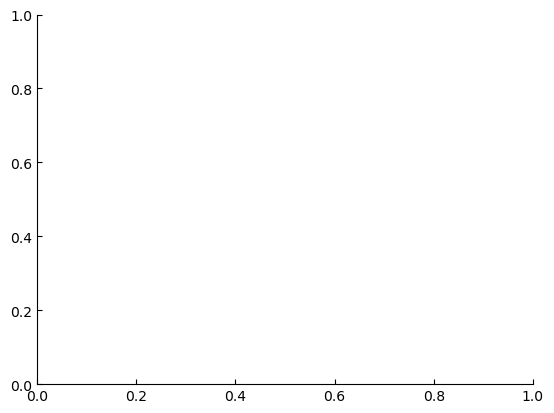

In [6]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df, x="iter", y="err", hue="particle", s=5)
plt.plot(pso_df.groupby("iter").err.min(), lw=2, color="r")
plt.ylabel("err")
plt.xlabel("iteration")
plt.ylim([0, 0.1])
ax.legend().set_visible(False)
plt.title("PSO Fitting Outputs")
plt.show()

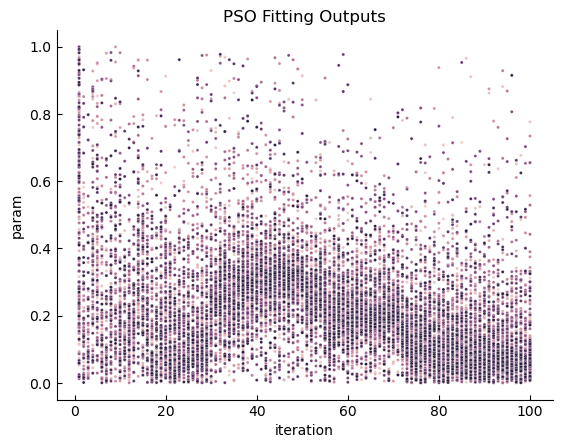

In [ ]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df, x="iter", y="para", hue="particle", s=5)
# plt.plot(pso_df.groupby("iter").err.min(), lw=2, color="r")
plt.ylabel("param")
plt.xlabel("iteration")
# plt.ylim([400000, 600000])
ax.legend().set_visible(False)
plt.title("PSO Fitting Outputs")
plt.show()